In [5]:
# ============================================================
# CELL 1 — Imports
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
from pathlib import Path


from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import (classification_report, confusion_matrix,
                             silhouette_score, mean_absolute_error, r2_score)
from sklearn.linear_model import LinearRegression

warnings.filterwarnings('ignore')

DB_PATH      = Path('../data/processed/superstore.db')
REPORTS_PATH = Path('../reports/')

def run_query(sql):
    with sqlite3.connect(DB_PATH) as conn:
        return pd.read_sql_query(sql, conn)

print("Libraries loaded.")

Libraries loaded.


In [18]:
import pandas as pd
import sqlite3

# ============================================================
# DATABASE PATH
# ============================================================

DB_PATH = r"..\data\processed\superstore.db"

# ============================================================
# LOAD CSV
# ============================================================

df = pd.read_csv(
    r"C:\Users\shokd\Desktop\Superstore\sales-revenue-intelligence\data\train.csv"
)

# ============================================================
# CREATE SQLITE CONNECTION
# ============================================================

conn = sqlite3.connect(DB_PATH)

# ============================================================
# CREATE TABLE
# ============================================================

df.to_sql(
    "sales",
    conn,
    if_exists="replace",
    index=False
)

conn.close()

print("sales table created successfully")

sales table created successfully


In [20]:
conn = sqlite3.connect(DB_PATH)

pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

,name
0,orders
1,sales


In [22]:
df_raw = run_query("SELECT * FROM sales")

In [25]:
df_raw['order_date']
df_raw['customer_id']
df_raw['product_id']
df_raw['sales']

0       261.9600
1       731.9400
2        14.6200
3       957.5775
4        22.3680
          ...   
9795      3.7980
9796     10.3680
9797    235.1880
9798     26.3760
9799     10.3840
Name: sales, Length: 9800, dtype: float64

In [27]:
# ============================================================
# CELL 2 — Build the customer feature table
# This single table feeds ALL THREE models.
# ============================================================

# ============================================================
# LOAD DATA
# ============================================================

df_raw = run_query("SELECT * FROM sales")

# ============================================================
# NORMALIZE COLUMN NAMES
# ============================================================

df_raw.columns = (
    df_raw.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('-', '_')
)

# ============================================================
# CONVERT DATE COLUMN
# Dataset format = DD/MM/YYYY
# ============================================================

df_raw['order_date'] = pd.to_datetime(
    df_raw['order_date'],
    format='%d/%m/%Y'
)

# ============================================================
# SNAPSHOT DATE
# ============================================================

SNAPSHOT_DATE = (
    df_raw['order_date'].max()
    + pd.Timedelta(days=1)
)

print(f"Snapshot date: {SNAPSHOT_DATE.date()}")

# ============================================================
# RFM FEATURE ENGINEERING
# ============================================================

rfm = df_raw.groupby('customer_id').agg(

    recency=(
        'order_date',
        lambda x: (SNAPSHOT_DATE - x.max()).days
    ),

    frequency=(
        'order_id',
        'nunique'
    ),

    monetary=(
        'sales',
        'sum'
    ),

    avg_order=(
        'sales',
        'mean'
    ),

    first_order=(
        'order_date',
        'min'
    ),

    last_order=(
        'order_date',
        'max'
    ),

    n_products=(
        'product_id',
        'nunique'
    ),

    n_categories=(
        'category',
        'nunique'
    ),

    segment=(
        'segment',
        'first'
    ),

    region=(
        'region',
        'first'
    )

).reset_index()

# ============================================================
# CUSTOMER TENURE
# ============================================================

rfm['tenure_days'] = (
    rfm['last_order']
    - rfm['first_order']
).dt.days

# ============================================================
# AVG DAYS BETWEEN ORDERS
# ============================================================

rfm['avg_days_between_orders'] = np.where(

    rfm['frequency'] > 1,

    rfm['tenure_days']
    / (rfm['frequency'] - 1),

    rfm['tenure_days']

)

# ============================================================
# CATEGORY DIVERSITY SCORE
# ============================================================

rfm['category_diversity'] = (
    rfm['n_categories'] / 3.0
)

# ============================================================
# OUTPUT
# ============================================================

print(f"\nCustomer feature table: {rfm.shape}")

print(
    rfm.describe()
    .round(1)
    .to_string()
)

Snapshot date: 2018-12-31

Customer feature table: (793, 14)
       recency  frequency  monetary  avg_order                 first_order                  last_order  n_products  n_categories  tenure_days  avg_days_between_orders  category_diversity
count    793.0      793.0     793.0      793.0                         793                         793       793.0         793.0        793.0                    793.0               793.0
mean     149.3        6.2    2851.9      227.4  2015-11-14 11:33:40.176544  2018-08-03 17:07:47.591425        12.3           2.7        993.2                    226.0                 0.9
min        1.0        1.0       4.8        2.4         2015-01-03 00:00:00         2015-10-22 00:00:00         1.0           1.0          0.0                      0.0                 0.3
25%       31.0        4.0    1081.5      115.9         2015-05-16 00:00:00         2018-06-29 00:00:00         8.0           3.0        820.0                    144.4                 1.0
50% 

In [36]:
# ============================================================
# CELL 3 — Engineer the churn label
# No column exists — we define churn from behaviour.
# This is what real analysts do.
# ============================================================

# Business rule: A customer has "churned" if they haven't
# ordered in the last 180 days of the dataset.
# This is a reasonable threshold for a retail store.
# In production, the business defines this — usually 90/180/365 days.

CHURN_THRESHOLD = 180

rfm['churned'] = (rfm['recency'] > CHURN_THRESHOLD).astype(int)

churn_rate = rfm['churned'].mean() * 100
print(f"Churn rate in dataset: {churn_rate:.1f}%")
print(rfm['churned'].value_counts().rename({0: 'Active', 1: 'Churned'}))

Churn rate in dataset: 25.9%
churned
Active     588
Churned    205
Name: count, dtype: int64


In [37]:
# ============================================================
# CELL 4 — Train the churn model
# ============================================================

FEATURES = [
    'recency', 'frequency', 'monetary', 'avg_order',
    'tenure_days', 'avg_days_between_orders',
    'n_products', 'category_diversity'
]

X = rfm[FEATURES]
y = rfm['churned']

# Split: 80% train, 20% test. Stratify keeps churn ratio equal in both.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Random Forest: robust, handles mixed scales, gives feature importance
model_churn = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced'  # handles imbalanced churn rates
)
model_churn.fit(X_train, y_train)

# Evaluate
y_pred  = model_churn.predict(X_test)
y_proba = model_churn.predict_proba(X_test)[:, 1]

print("=" * 50)
print("CHURN MODEL — CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['Active', 'Churned']))

# Cross-validation: more honest than a single train/test split
cv_scores = cross_val_score(model_churn, X, y, cv=5, scoring='roc_auc')
print(f"Cross-validated ROC-AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

CHURN MODEL — CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Active       1.00      1.00      1.00       118
     Churned       1.00      1.00      1.00        41

    accuracy                           1.00       159
   macro avg       1.00      1.00      1.00       159
weighted avg       1.00      1.00      1.00       159

Cross-validated ROC-AUC: 1.000 ± 0.000


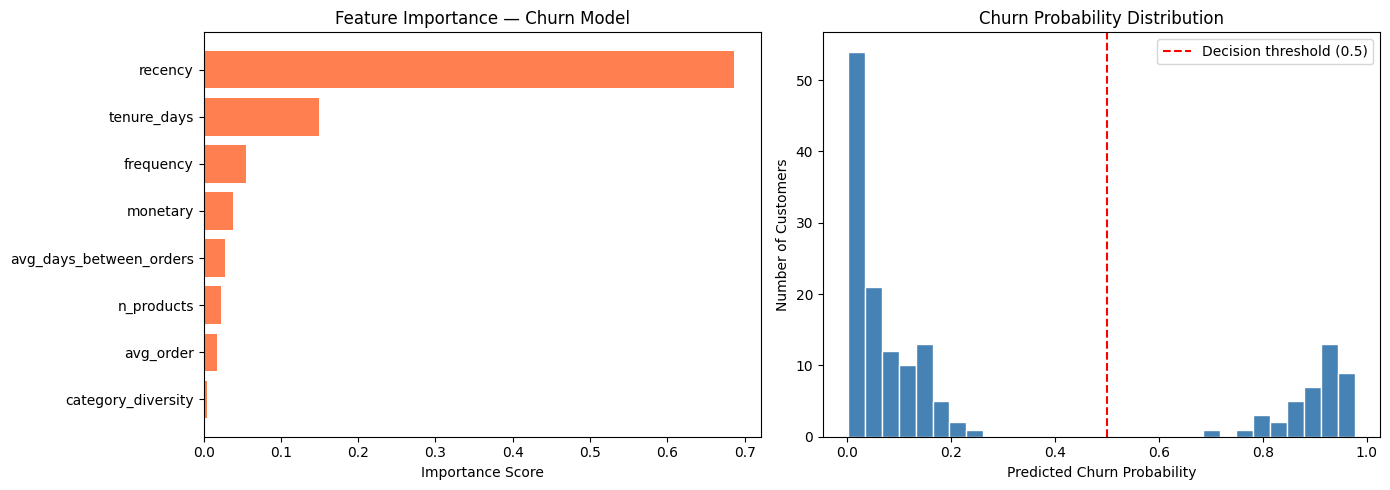


Customers by churn risk:
churn_risk
Low risk       587
High risk      205
Medium risk      1
Name: count, dtype: int64


In [38]:
# ============================================================
# CELL 5 — Feature importance + churn probability scores
# ============================================================

# Feature importance: what did the model actually learn?
importance_df = pd.DataFrame({
    'feature':   FEATURES,
    'importance': model_churn.feature_importances_
}).sort_values('importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Feature importance
axes[0].barh(importance_df['feature'], importance_df['importance'], color='coral')
axes[0].set_title('Feature Importance — Churn Model')
axes[0].set_xlabel('Importance Score')

# Chart 2: Churn probability distribution
axes[1].hist(y_proba, bins=30, color='steelblue', edgecolor='white')
axes[1].axvline(0.5, color='red', linestyle='--', label='Decision threshold (0.5)')
axes[1].set_title('Churn Probability Distribution')
axes[1].set_xlabel('Predicted Churn Probability')
axes[1].set_ylabel('Number of Customers')
axes[1].legend()

plt.tight_layout()
plt.savefig(REPORTS_PATH / 'churn_model.png', dpi=150, bbox_inches='tight')
plt.show()

# Add churn scores back to the customer table
rfm['churn_probability'] = model_churn.predict_proba(X)[:, 1]
rfm['churn_risk'] = pd.cut(
    rfm['churn_probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low risk', 'Medium risk', 'High risk']
)

print("\nCustomers by churn risk:")
print(rfm['churn_risk'].value_counts())

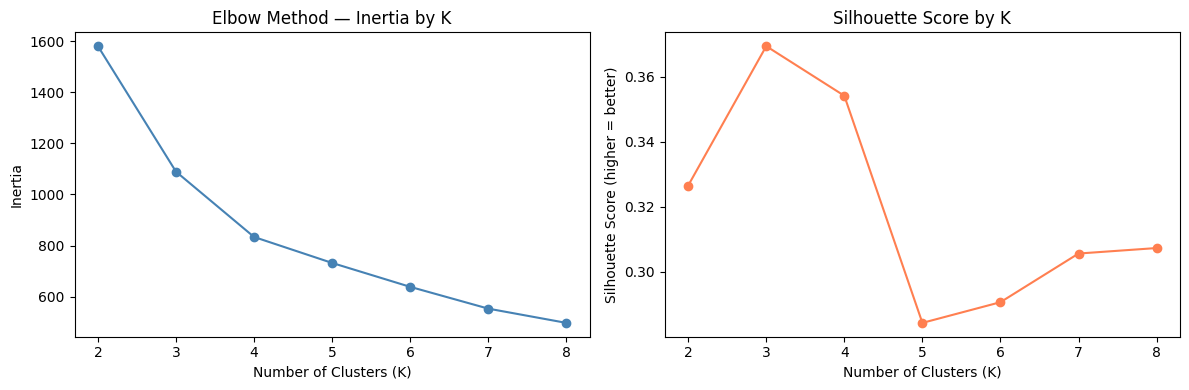

Look at both charts: choose K where inertia bends AND silhouette peaks.
For Superstore data, K=4 typically works well.


In [39]:
# ============================================================
# CELL 6 — K-Means clustering on RFM features
# ============================================================

# K-Means needs scaled features — RFM values are on very different scales
# (recency in days vs monetary in dollars)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['recency', 'frequency', 'monetary']])

# Find the optimal number of clusters using the Elbow method
inertias    = []
silhouettes = []
K_RANGE     = range(2, 9)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_RANGE, inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow Method — Inertia by K')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_RANGE, silhouettes, marker='o', color='coral')
axes[1].set_title('Silhouette Score by K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score (higher = better)')

plt.tight_layout()
plt.savefig(REPORTS_PATH / 'kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

print("Look at both charts: choose K where inertia bends AND silhouette peaks.")
print("For Superstore data, K=4 typically works well.")

In [40]:
# ============================================================
# CELL 7 — Fit final K-Means model and name the segments
# ============================================================

OPTIMAL_K = 4  # adjust based on your elbow/silhouette charts

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
rfm['cluster'] = km_final.fit_predict(rfm_scaled)

# Profile each cluster — what does it look like?
cluster_profile = rfm.groupby('cluster').agg(
    customers   = ('customer_id', 'count'),
    avg_recency = ('recency',     'mean'),
    avg_freq    = ('frequency',   'mean'),
    avg_revenue = ('monetary',    'mean'),
    avg_churn_p = ('churn_probability', 'mean')
).round(1)

print("Cluster profiles:")
print(cluster_profile.to_string())

# Give meaningful business names to each cluster
# These will differ slightly for each run — read the profile and assign:
#   Low recency + high freq + high monetary = Champions
#   Medium recency + medium freq            = Loyal Customers
#   High recency + low freq                 = At Risk
#   Very high recency + very low freq       = Lost

SEGMENT_NAMES = {
    0: 'Champions',       # adjust these based on YOUR cluster profiles
    1: 'Loyal Customers',
    2: 'At Risk',
    3: 'Lost'
}

rfm['segment_name'] = rfm['cluster'].map(SEGMENT_NAMES)
print("\nCustomers per segment:")
print(rfm['segment_name'].value_counts())

Cluster profiles:
         customers  avg_recency  avg_freq  avg_revenue  avg_churn_p
cluster                                                            
0              279         71.1       8.5       3226.8          0.1
1               99        556.3       3.6       1403.9          0.9
2              347        101.6       4.7       1712.4          0.2
3               68        120.7       8.2       9236.5          0.2

Customers per segment:
segment_name
At Risk            347
Champions          279
Loyal Customers     99
Lost                68
Name: count, dtype: int64


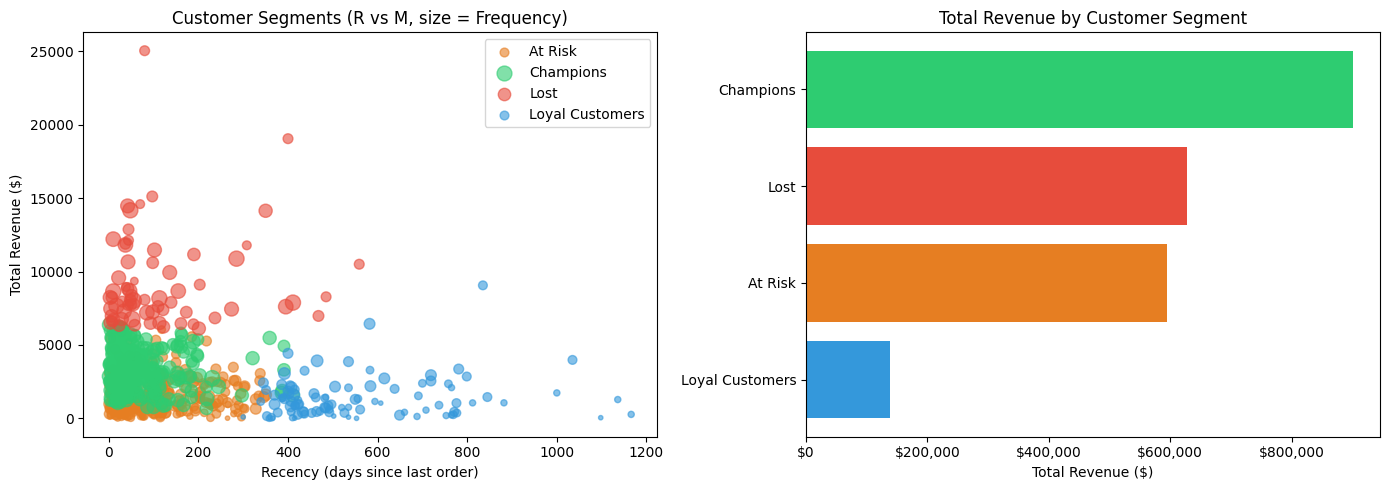

In [41]:
# ============================================================
# CELL 8 — Visualise the segments
# ============================================================

COLORS = {'Champions': '#2ecc71', 'Loyal Customers': '#3498db',
          'At Risk': '#e67e22', 'Lost': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RFM scatter: Recency vs Monetary, size = Frequency
for seg, grp in rfm.groupby('segment_name'):
    axes[0].scatter(grp['recency'], grp['monetary'],
                    s=grp['frequency']*10, alpha=0.6,
                    label=seg, color=COLORS.get(seg, 'gray'))
axes[0].set_title('Customer Segments (R vs M, size = Frequency)')
axes[0].set_xlabel('Recency (days since last order)')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].legend()

# Revenue contribution per segment
seg_revenue = rfm.groupby('segment_name')['monetary'].sum().sort_values(ascending=True)
bar_colors  = [COLORS.get(s, 'gray') for s in seg_revenue.index]
axes[1].barh(seg_revenue.index, seg_revenue.values, color=bar_colors)
axes[1].set_title('Total Revenue by Customer Segment')
axes[1].set_xlabel('Total Revenue ($)')
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

plt.tight_layout()
plt.savefig(REPORTS_PATH / 'customer_segments.png', dpi=150, bbox_inches='tight')
plt.show()

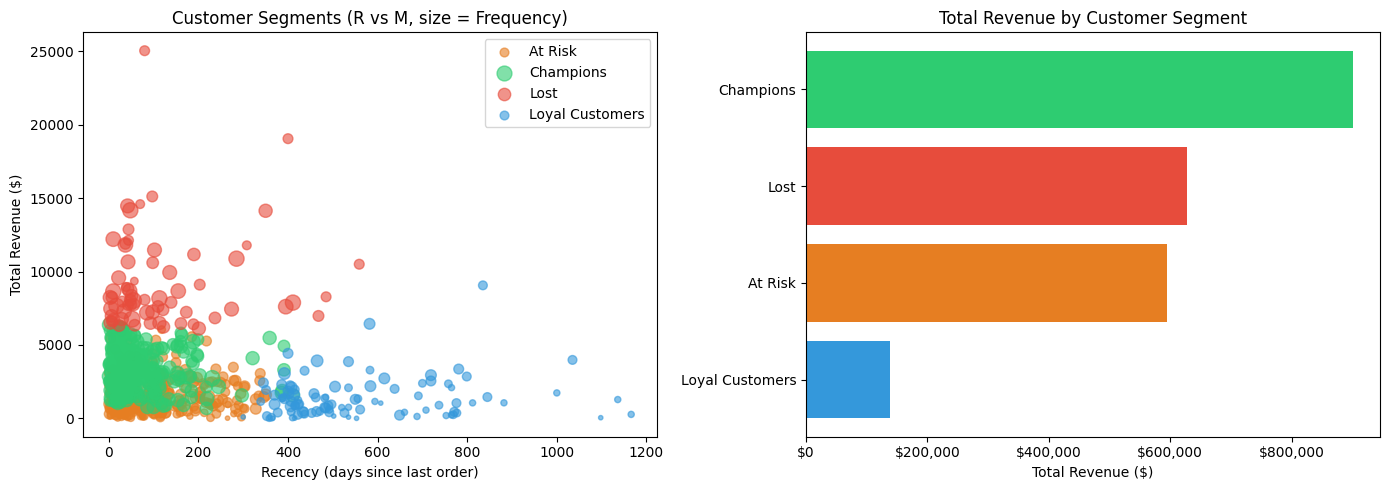

In [42]:
# ============================================================
# CELL 8 — Visualise the segments
# ============================================================

COLORS = {'Champions': '#2ecc71', 'Loyal Customers': '#3498db',
          'At Risk': '#e67e22', 'Lost': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RFM scatter: Recency vs Monetary, size = Frequency
for seg, grp in rfm.groupby('segment_name'):
    axes[0].scatter(grp['recency'], grp['monetary'],
                    s=grp['frequency']*10, alpha=0.6,
                    label=seg, color=COLORS.get(seg, 'gray'))
axes[0].set_title('Customer Segments (R vs M, size = Frequency)')
axes[0].set_xlabel('Recency (days since last order)')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].legend()

# Revenue contribution per segment
seg_revenue = rfm.groupby('segment_name')['monetary'].sum().sort_values(ascending=True)
bar_colors  = [COLORS.get(s, 'gray') for s in seg_revenue.index]
axes[1].barh(seg_revenue.index, seg_revenue.values, color=bar_colors)
axes[1].set_title('Total Revenue by Customer Segment')
axes[1].set_xlabel('Total Revenue ($)')
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

plt.tight_layout()
plt.savefig(REPORTS_PATH / 'customer_segments.png', dpi=150, bbox_inches='tight')
plt.show()

In [45]:
# ============================================================
# CELL 9 — Monthly Revenue Time Series
# ============================================================

monthly = run_query("""

SELECT

    SUBSTR("Order Date", -4) AS order_year,

    SUBSTR("Order Date", 4, 2) AS order_month,

    SUM("Sales") AS revenue,

    COUNT(DISTINCT "Order ID") AS orders

FROM sales

GROUP BY
    SUBSTR("Order Date", -4),
    SUBSTR("Order Date", 4, 2)

ORDER BY
    order_year,
    order_month

""")

monthly.head()

,order_year,order_month,revenue,orders
0,2015,01,14205.707,30
1,2015,02,4519.892,28
2,2015,03,55205.797,69
3,2015,04,27906.855,63
4,2015,05,23644.303,68


In [48]:
# ============================================================
# CREATE DATE COLUMN
# ============================================================

monthly['date'] = pd.to_datetime(
    monthly['order_year']
    + '-'
    + monthly['order_month']
    + '-01'
)

monthly.head()

,order_year,order_month,revenue,orders,date
0,2015,01,14205.707,30,2015-01-01
1,2015,02,4519.892,28,2015-02-01
2,2015,03,55205.797,69,2015-03-01
3,2015,04,27906.855,63,2015-04-01
4,2015,05,23644.303,68,2015-05-01


In [53]:
# ============================================================
# TIME SERIES FEATURE ENGINEERING
# ============================================================

# Sort by date
monthly = monthly.sort_values('date')

# ============================================================
# TIME FEATURES
# ============================================================

monthly['month_num'] = range(len(monthly))

monthly['month_of_year'] = (
    monthly['date'].dt.month
)

monthly['quarter'] = (
    monthly['date'].dt.quarter
)

# ============================================================
# LAG FEATURES
# ============================================================

monthly['revenue_lag1'] = (
    monthly['revenue'].shift(1)
)

monthly['revenue_lag2'] = (
    monthly['revenue'].shift(2)
)

# ============================================================
# ROLLING FEATURES
# ============================================================

monthly['rolling3'] = (
    monthly['revenue']
    .rolling(3)
    .mean()
)

# ============================================================
# REMOVE NaN VALUES
# ============================================================

monthly_clean = (
    monthly
    .dropna()
    .reset_index(drop=True)
)

# ============================================================
# CHECK DATA
# ============================================================

monthly_clean.head()

,order_year,order_month,revenue,orders,date,month_num,month_of_year,quarter,revenue_lag1,revenue_lag2,rolling3
0,2015,03,55205.7970,69,2015-03-01,2,3,1,4519.8920,14205.707,24643.798667
1,2015,04,27906.8550,63,2015-04-01,3,4,2,55205.7970,4519.892,29210.848000
2,2015,05,23644.3030,68,2015-05-01,4,5,2,27906.8550,55205.797,35585.651667
3,2015,06,34322.9356,64,2015-06-01,5,6,2,23644.3030,27906.855,28624.697867
4,2015,07,33781.5430,64,2015-07-01,6,7,3,34322.9356,23644.303,30582.927200


In [55]:
FEATURE_COLS = [
    'month_num',
    'month_of_year',
    'quarter',
    'revenue_lag1',
    'revenue_lag2',
    'rolling3'
]

X_ts = monthly_clean[FEATURE_COLS]

y_ts = monthly_clean['revenue']

Revenue Forecast — MAE: $0  |  R²: 1.000


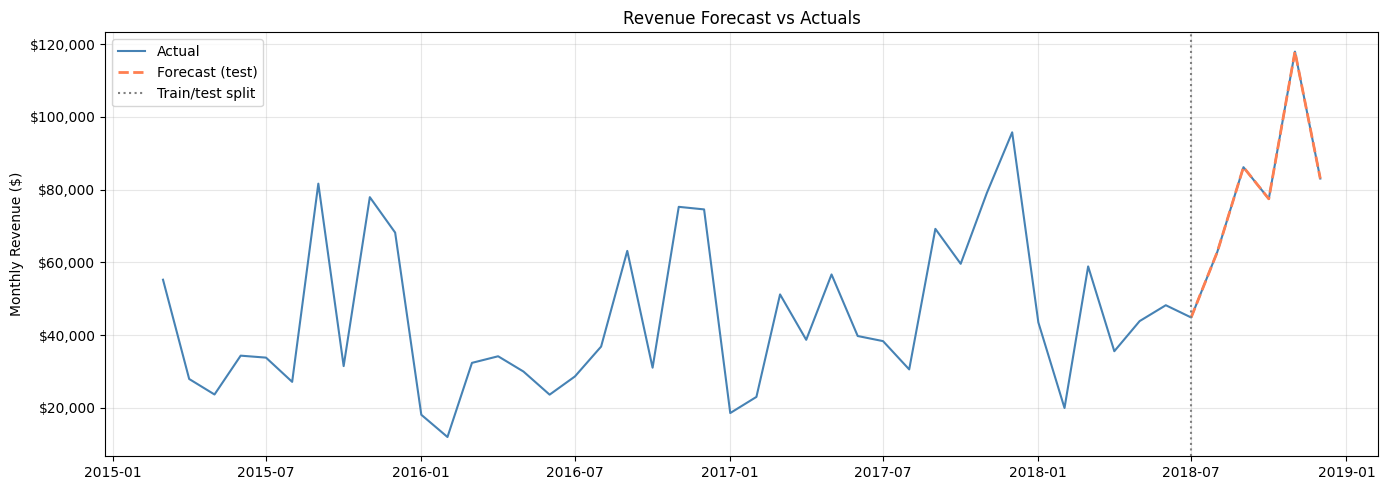

In [57]:
# ============================================================
# CELL 10 — Train model and generate 6-month forecast
# ============================================================

FEATURE_COLS = [
    'month_num', 'month_of_year', 'quarter',
    'revenue_lag1', 'revenue_lag2', 'rolling3'
]

X_ts = monthly_clean[FEATURE_COLS]
y_ts = monthly_clean['revenue']

# Train on all but the last 6 months, test on last 6
split_idx = len(monthly_clean) - 6
X_train_ts, X_test_ts = X_ts.iloc[:split_idx], X_ts.iloc[split_idx:]
y_train_ts, y_test_ts = y_ts.iloc[:split_idx], y_ts.iloc[split_idx:]

model_rev = LinearRegression()
model_rev.fit(X_train_ts, y_train_ts)

y_pred_ts = model_rev.predict(X_test_ts)

mae = mean_absolute_error(y_test_ts, y_pred_ts)
r2  = r2_score(y_test_ts, y_pred_ts)
print(f"Revenue Forecast — MAE: ${mae:,.0f}  |  R²: {r2:.3f}")

# Visualise actual vs predicted
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_clean['date'], y_ts, label='Actual', color='steelblue', linewidth=1.5)
ax.plot(monthly_clean['date'].iloc[split_idx:], y_pred_ts,
        label='Forecast (test)', color='coral', linewidth=2, linestyle='--')
ax.axvline(monthly_clean['date'].iloc[split_idx], color='gray',
           linestyle=':', label='Train/test split')
ax.set_title('Revenue Forecast vs Actuals')
ax.set_ylabel('Monthly Revenue ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(REPORTS_PATH / 'revenue_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

In [58]:
# ============================================================
# CELL 11 — Save all model outputs for the dashboard
# ============================================================

# Save the enriched customer table (feeds Streamlit in Phase 4)
rfm.to_csv('../data/processed/customer_segments.csv', index=False)

# Save monthly with forecast
monthly_clean.to_csv('../data/processed/monthly_revenue.csv', index=False)

print("Saved:")
print("  data/processed/customer_segments.csv")
print("  data/processed/monthly_revenue.csv")
print(f"\nCustomer table columns: {rfm.columns.tolist()}")
print(f"\nFinal dataset shape: {rfm.shape}")

Saved:
  data/processed/customer_segments.csv
  data/processed/monthly_revenue.csv

Customer table columns: ['customer_id', 'recency', 'frequency', 'monetary', 'avg_order', 'first_order', 'last_order', 'n_products', 'n_categories', 'segment', 'region', 'tenure_days', 'avg_days_between_orders', 'category_diversity', 'churned', 'churn_probability', 'churn_risk', 'cluster', 'segment_name']

Final dataset shape: (793, 19)
